# EDA: Аналіз датасету бджіл (Pose Estimation)

Розвідувальний аналіз даних для задачі визначення пози бджіл на прилітній дошці вулика.

**Датасет:** YOLO Pose формат — кожна бджола анотована bounding box та двома ключовими точками (голова, жало).

**Формат анотацій:** `class x y w h px1 py1 px2 py2` (нормалізовані координати 0–1)

**Структура аналізу:**
1. Завантаження та перевірка якості даних
2. Feature engineering (ID вулика, кут орієнтації)
3. Загальна статистика та розподіл за вуликами
4. Часова динаміка та розподіл кількості бджіл
5. Аналіз орієнтації бджіл
6. Просторовий аналіз (теплові карти)
7. Кореляційний аналіз та візуалізація прикладів

In [1]:
import pandas as pd
import numpy as np
import os
import re
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm

## 1. Завантаження даних

In [2]:
# Шляхи до даних
LABEL_DIR = "../data/raw/pose/labels"
IMAGE_DIR = "../data/raw/pose/images"

def load_pose_data(label_dir):
    """Завантажує анотації YOLO Pose з .txt файлів у DataFrame."""
    records = []
    files = sorted([f for f in os.listdir(label_dir) if f.endswith('.txt')])
    
    for filename in files:
        with open(os.path.join(label_dir, filename), 'r') as f:
            for line in f:
                vals = list(map(float, line.split()))
                # формат: class x y w h px1 py1 px2 py2
                records.append([filename] + vals)
                
    cols = ['file', 'class', 'x', 'y', 'w', 'h', 'px1', 'py1', 'px2', 'py2']
    return pd.DataFrame(records, columns=cols)

# Завантаження та збереження через CSV
df = load_pose_data(LABEL_DIR)
df.to_csv("../data/raw/eda_metadata.csv", index=False)
df = pd.read_csv("../data/raw/eda_metadata.csv")
df.head()

,file,class,x,y,w,h,px1,py1,px2,py2
0,20230609a102.txt,0.0,0.155990,0.940278,0.041146,0.119444,0.160417,0.888889,0.152604,0.990741
1,20230609a102.txt,0.0,0.281510,0.944907,0.029687,0.049074,0.291146,0.927778,0.270313,0.962963
2,20230609a102.txt,0.0,0.390104,0.850463,0.030208,0.065741,0.400521,0.824074,0.380208,0.875926
3,20230609a102.txt,0.0,0.297917,0.315741,0.038542,0.038889,0.281250,0.318519,0.311458,0.314815
4,20230609a108.txt,0.0,0.276823,0.311111,0.036979,0.038889,0.260417,0.314815,0.291667,0.310185


## 2. Перевірка якості даних

In [3]:
print("--- Інформація про датасет ---")
df.info()
print("\nПропуски:\n", df.isnull().sum())

--- Інформація про датасет ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3668 entries, 0 to 3667
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   file    3668 non-null   object 
 1   class   3668 non-null   float64
 2   x       3668 non-null   float64
 3   y       3668 non-null   float64
 4   w       3668 non-null   float64
 5   h       3668 non-null   float64
 6   px1     3668 non-null   float64
 7   py1     3668 non-null   float64
 8   px2     3668 non-null   float64
 9   py2     3668 non-null   float64
dtypes: float64(9), object(1)
memory usage: 286.7+ KB

Пропуски:
 file     0
class    0
x        0
y        0
w        0
h        0
px1      0
py1      0
px2      0
py2      0
dtype: int64


## 3. Feature Engineering

Додаємо похідні ознаки перед аналізом:
- **hive_id** — ідентифікатор вулика, витягнутий з імені файлу (паттерн `YYYYMMDD+літера`)
- **angle / angle_deg** — кут орієнтації бджоли (від голови до жала)

In [4]:
# Ідентифікатор вулика з назви файлу (напр., "20230609a" з "20230609a102.txt")
def extract_hive_id(filename):
    match = re.match(r"(\d{8}[a-z])", filename)
    return match.group(1) if match else "unknown"

df['hive_id'] = df['file'].apply(extract_hive_id)

# Кут орієнтації бджоли (від голови до жала)
df['angle'] = np.arctan2(df['py2'] - df['py1'], df['px2'] - df['px1'])
df['angle_deg'] = np.degrees(df['angle'])

print(f"Додано ознаки: hive_id, angle, angle_deg")
print(f"Унікальні вулики: {df['hive_id'].nunique()} — {sorted(df['hive_id'].unique())}")
df[['file', 'hive_id', 'angle_deg']].head()

Додано ознаки: hive_id, angle, angle_deg
Унікальні вулики: 8 — ['20230609a', '20230609b', '20230609c', '20230609d', '20230609e', '20230711a', '20230711b', '20230711c']


,file,hive_id,angle_deg
0,20230609a102.txt,20230609a,94.386531
1,20230609a102.txt,20230609a,120.629729
2,20230609a102.txt,20230609a,111.392742
3,20230609a102.txt,20230609a,-6.990515
4,20230609a108.txt,20230609a,-8.427633


## 4. Загальна статистика датасету

Агрегуємо кількість бджіл по кадрах, враховуючи зображення без анотацій (порожні кадри).

In [5]:
# Кількість бджіл на кадр (включаючи порожні кадри з папки images)
frame_stats = df.groupby('file').size().reset_index(name='bee_count')

all_image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')])
all_files_df = pd.DataFrame({'file': [f.replace('.jpg', '.txt') for f in all_image_files]})
frame_stats = pd.merge(all_files_df, frame_stats, on='file', how='left').fillna(0)
frame_stats['bee_count'] = frame_stats['bee_count'].astype(int)

# Додаємо hive_id до frame_stats для подальшого аналізу
frame_stats['hive_id'] = frame_stats['file'].apply(extract_hive_id)

# Базові метрики
total_images = len(frame_stats)
total_bees = frame_stats['bee_count'].sum()
avg_bees = frame_stats['bee_count'].mean()
max_bees = frame_stats['bee_count'].max()
empty_frames = len(frame_stats[frame_stats['bee_count'] == 0])

print("=== ЗАГАЛЬНА СТАТИСТИКА ДАТАСЕТУ ===")
print(f"Кількість зображень: {total_images}")
print(f"Загальна кількість анотованих бджіл: {total_bees}")
print(f"Середня кількість бджіл на кадрі: {avg_bees:.2f}")
print(f"Максимальна кількість бджіл на кадрі: {max_bees}")
print(f"Кількість кадрів без бджіл: {empty_frames} ({empty_frames/total_images*100:.1f}%)")
print(f"\nРозподіл кадрів за вуликами:")
print(frame_stats['hive_id'].value_counts())

=== ЗАГАЛЬНА СТАТИСТИКА ДАТАСЕТУ ===
Кількість зображень: 400
Загальна кількість анотованих бджіл: 3668
Середня кількість бджіл на кадрі: 9.17
Максимальна кількість бджіл на кадрі: 33
Кількість кадрів без бджіл: 0 (0.0%)

Розподіл кадрів за вуликами:
hive_id
20230609a    50
20230609b    50
20230609c    50
20230609d    50
20230609e    50
20230711a    50
20230711b    50
20230711c    50
Name: count, dtype: int64


## 5. Розподіл кількості бджіл за вуликами

/tmp/ipykernel_262962/4203120741.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=frame_stats, x='hive_id', y='bee_count', palette='Set2')


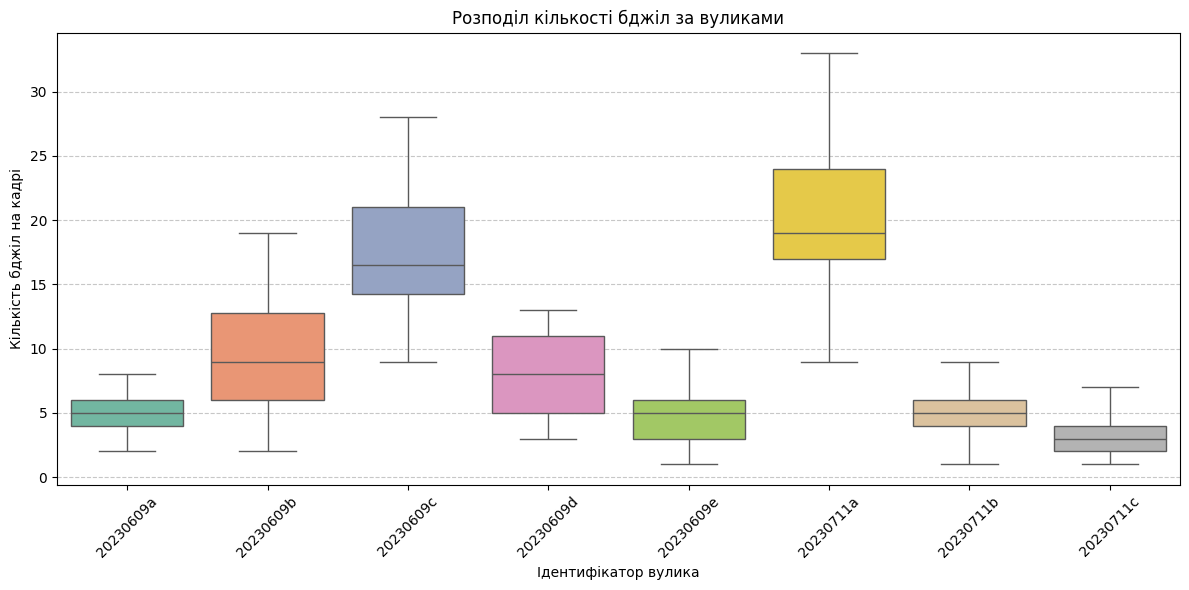

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=frame_stats, x='hive_id', y='bee_count', palette='Set2')
plt.title('Розподіл кількості бджіл за вуликами')
plt.xlabel('Ідентифікатор вулика')
plt.ylabel('Кількість бджіл на кадрі')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Часова динаміка та розподіл кількості бджіл

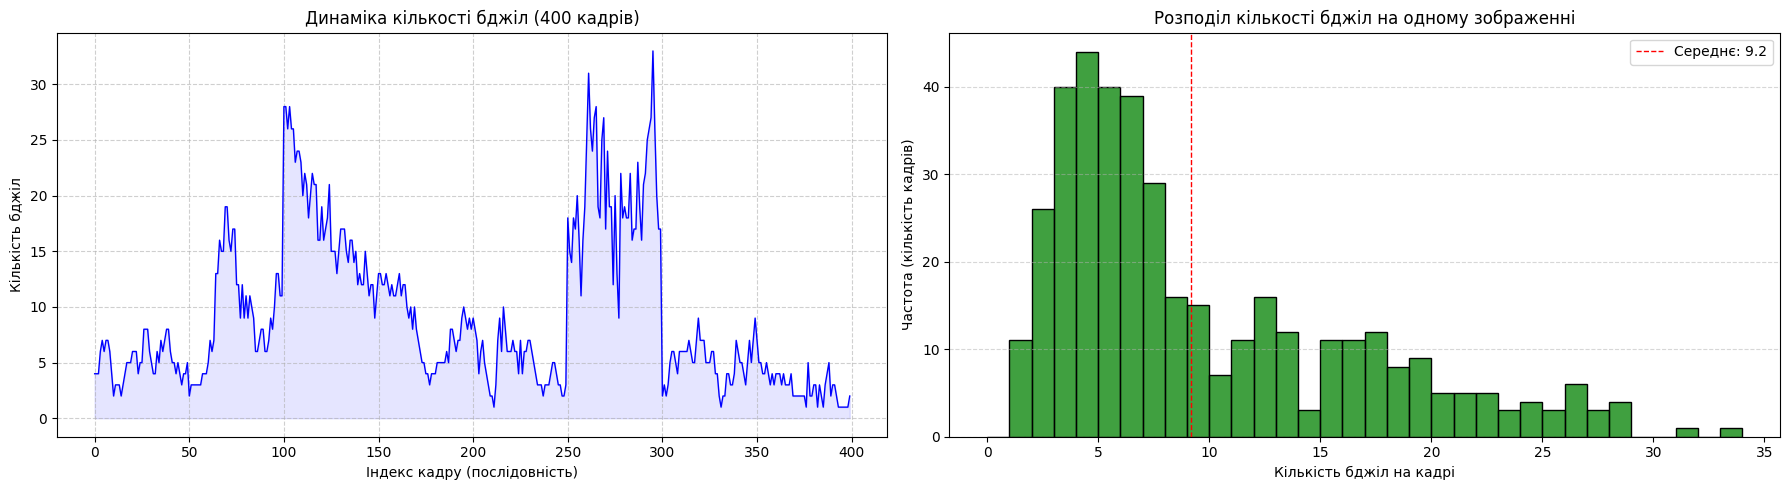

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Лівий графік — динаміка по кадрах
axes[0].plot(range(len(frame_stats)), frame_stats['bee_count'], color='blue', linewidth=1)
axes[0].fill_between(range(len(frame_stats)), frame_stats['bee_count'], color='blue', alpha=0.1)
axes[0].set_title(f'Динаміка кількості бджіл ({total_images} кадрів)')
axes[0].set_xlabel('Індекс кадру (послідовність)')
axes[0].set_ylabel('Кількість бджіл')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Правий графік — гістограма розподілу
sns.histplot(frame_stats['bee_count'], bins=range(0, max_bees + 2), kde=False, 
             color='green', ax=axes[1])
axes[1].axvline(avg_bees, color='red', linestyle='dashed', linewidth=1, 
                label=f'Середнє: {avg_bees:.1f}')
axes[1].set_title('Розподіл кількості бджіл на одному зображенні')
axes[1].set_xlabel('Кількість бджіл на кадрі')
axes[1].set_ylabel('Частота (кількість кадрів)')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Аналіз орієнтації бджіл

Розподіл кутів між головою (px1, py1) та жалом (px2, py2) — показує переважні напрямки руху.

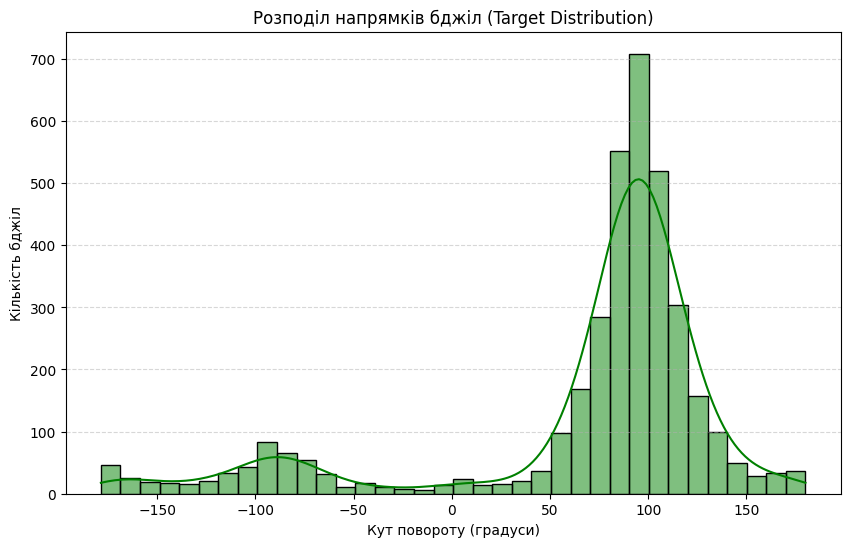

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['angle_deg'], bins=36, kde=True, color='green')
plt.title("Розподіл напрямків бджіл (Target Distribution)")
plt.xlabel("Кут повороту (градуси)")
plt.ylabel("Кількість бджіл")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 8. Просторовий аналіз

### 8.1 KDE Heatmap (нормалізовані координати)
Щільність центрів bounding box'ів на нормалізованому полі 0–1.

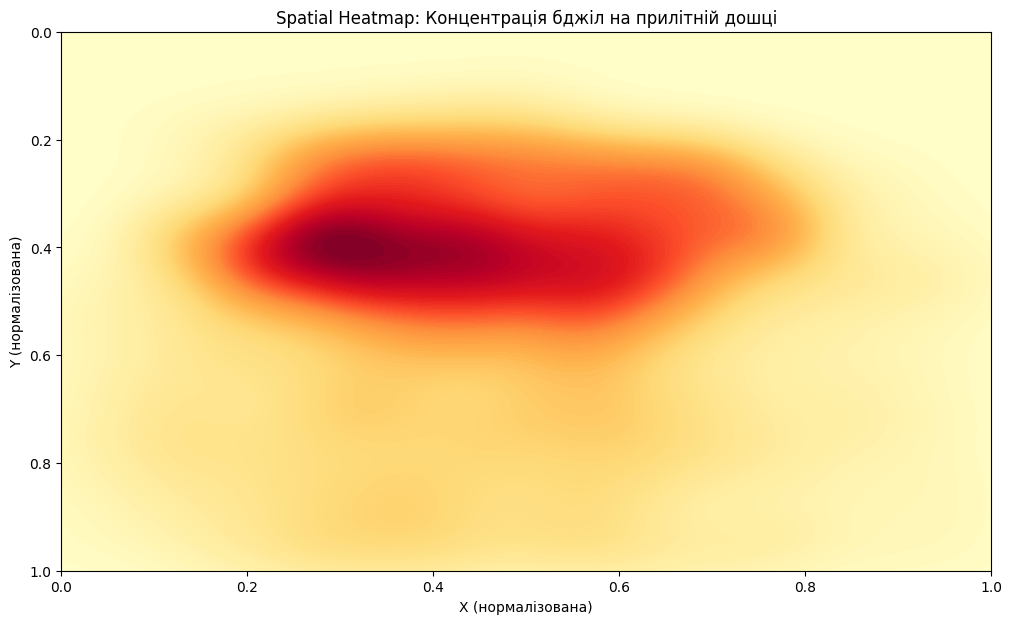

In [9]:
plt.figure(figsize=(12, 7))
sns.kdeplot(x=df['x'], y=df['y'], fill=True, cmap="YlOrRd", thresh=0, levels=100)
plt.title("Spatial Heatmap: Концентрація бджіл на прилітній дошці")
plt.xlim(0, 1)
plt.ylim(1, 0)  # Інвертуємо Y, бо в зображеннях 0 зверху
plt.xlabel("X (нормалізована)")
plt.ylabel("Y (нормалізована)")
plt.show()

### 8.2 Hexbin Heatmap (піксельні координати на фоні зображення)

Та сама просторова інформація, але накладена на реальний кадр для наочності. Координати з `df` перетворюються в пікселі на основі розмірів обраного фонового зображення.

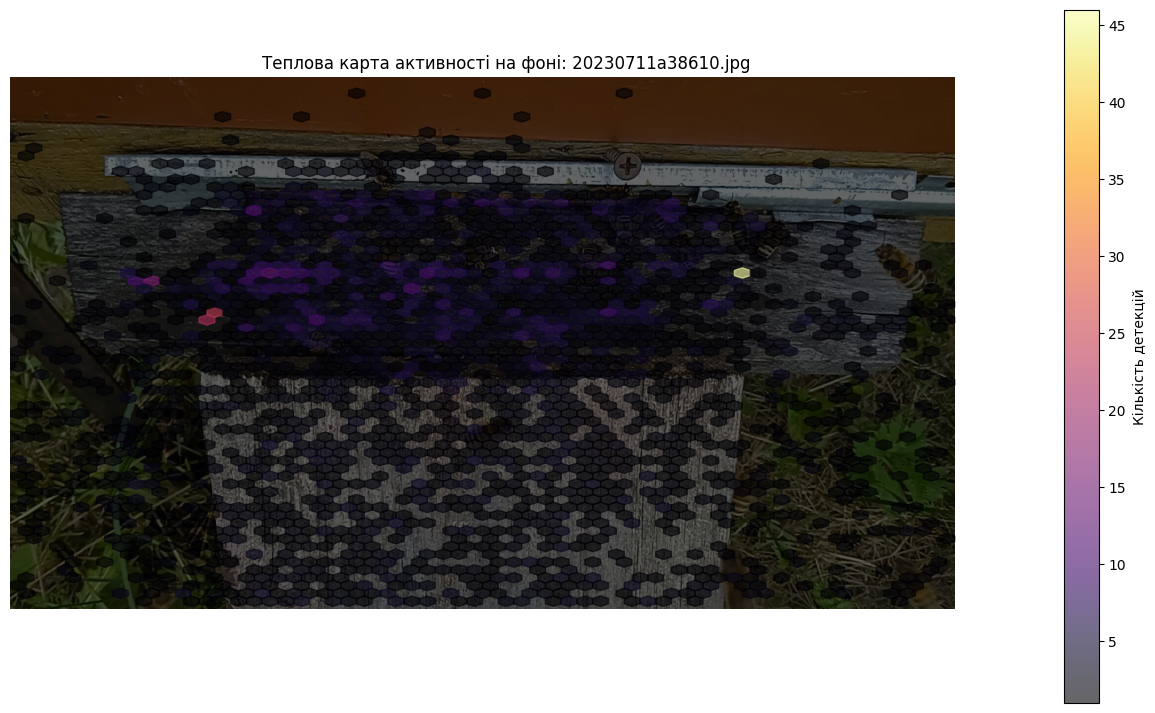

In [10]:
# Вибір випадкового фонового зображення
all_images = glob.glob(os.path.join(IMAGE_DIR, '**', '*.jpg'), recursive=True)
background_path = all_images[np.random.randint(0, len(all_images))]

img_bgr = cv2.imread(background_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_h, img_w, _ = img_rgb.shape
img_dark = (img_rgb * 0.4).astype(np.uint8)

# Переведення нормалізованих координат з df у піксельні
all_x_px = (df['x'] * img_w).tolist()
all_y_px = (df['y'] * img_h).tolist()

# Візуалізація
plt.figure(figsize=(16, 9))
plt.imshow(img_dark)

hb = plt.hexbin(all_x_px, all_y_px, gridsize=60, cmap='inferno',
                mincnt=1, alpha=0.6, extent=[0, img_w, 0, img_h])
cb = plt.colorbar(hb, ax=plt.gca())
cb.set_label('Кількість детекцій')

plt.title(f'Теплова карта активності на фоні: {os.path.basename(background_path)}')
plt.axis('off')
plt.show()

## 9. Кореляційний аналіз геометричних ознак

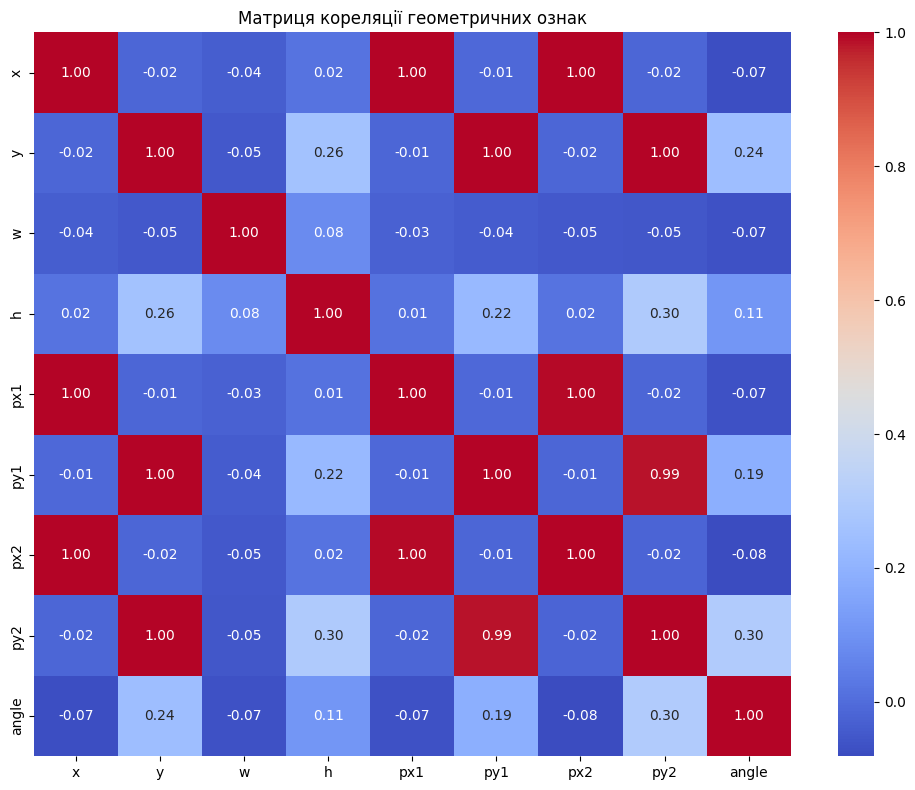

In [11]:
plt.figure(figsize=(10, 8))
cv_features = ['x', 'y', 'w', 'h', 'px1', 'py1', 'px2', 'py2', 'angle']
sns.heatmap(df[cv_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матриця кореляції геометричних ознак")
plt.tight_layout()
plt.show()

## 10. Візуалізація прикладів з анотаціями

Випадкова вибірка зображень з нанесеними ключовими точками: голова (синя) та жало (червона).

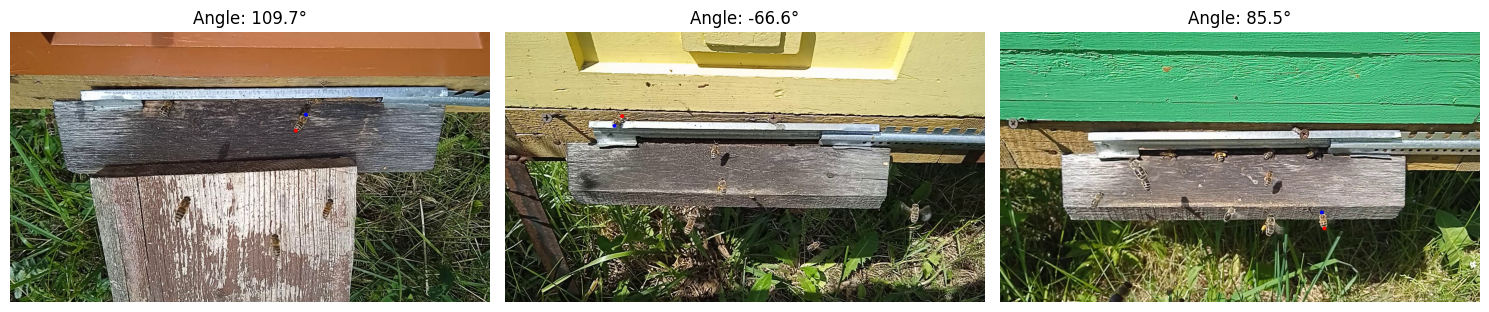

In [12]:
def visualize_sample(df, img_dir, n=3):
    """Візуалізація випадкових зображень з ключовими точками."""
    sample = df.sample(n)
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    
    for i, (idx, row) in enumerate(sample.iterrows()):
        img_path = os.path.join(img_dir, row['file'].replace('.txt', '.jpg'))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        h, w_img, _ = img.shape
        # Голова — синя, жало — червона
        cv2.circle(img, (int(row['px1'] * w_img), int(row['py1'] * h)), 8, (0, 0, 255), -1)
        cv2.circle(img, (int(row['px2'] * w_img), int(row['py2'] * h)), 8, (255, 0, 0), -1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"Angle: {row['angle_deg']:.1f}°")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_sample(df, IMAGE_DIR)